<a href="https://colab.research.google.com/github/manavdhelia/ML-for-engineers/blob/main/California_housing_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ECE 601: Linear Regression with California Housing Dataset**

# Problem 1: Implement both standard and stochastic gradient descent as done. Use 1000 iterations for batch gradient descent and 100 epochs for stochastic gradient descent and set the step size to 10^-4.
Our goal is to set up a regression model where the median house value is predicted from the other numerical variables in the dataset.

# 1. Import Libraries and Load Data
 We start by collecting the data and showing the first few rows.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True).frame.copy()

print("Dataset shape:", housing.shape)
housing.head()

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#2. Data Exploration and Preprocessing

Remover samples where y > 5 and check missing values (should be none)

In [5]:
print("\nMissing values:\n", housing.isnull().sum())

# Remove samples where y > 5
housing = housing[housing["MedHouseVal"] <= 5].copy()
print("\nCleaned dataset shape:", housing.shape)

print("\nDataset statistics:")
print(housing.describe())


Missing values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Cleaned dataset shape: (19675, 9)

Dataset statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  19675.000000  19675.000000  19675.000000  19675.000000  19675.000000   
mean       3.676717     28.386277      5.360901      1.096618   1440.812198   
std        1.570272     12.509113      2.292538      0.451839   1143.648725   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.526800     18.000000      4.414568      1.005894    796.000000   
50%        3.450000     28.000000      5.184322      1.048622   1179.000000   
75%        4.582600     37.000000      5.970677      1.099338   1746.000000   
max       15.000100     52.000000    132.533333     34.066667  35682.000000   

           AveOccup      Latitude     Longitude 

Next, we check the correlation among the features to preview which features may be most helpful in prediction.

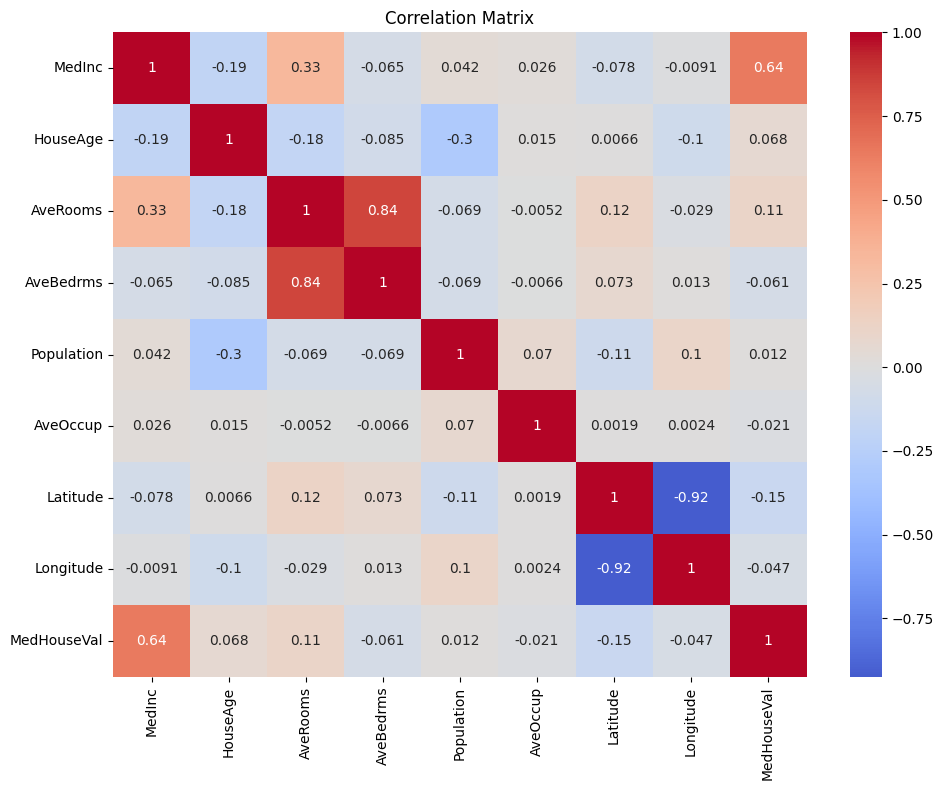

In [6]:
# Visualize correlations
plt.figure(figsize=(10, 8))
sns.heatmap(housing.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# 3. Prepare Data for Regression
Some common steps for prediction can be done optionally: normalization/centering (remove mean, normalize by variance, to obtain variables following standard Gaussian distribution). We also add a 1 at the end of each sample to allow for an offset/bias ( 𝜃0 ).

In [7]:
X = housing[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']].values
y = housing['MedHouseVal'].values.reshape(-1, 1)

# Standardize features (mean=0, std=1)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_normalized = (X - X_mean) / X_std

# Add bias term (column of ones)
X_with_bias = np.c_[np.ones((X.shape[0], 1)), X]
X_normalized_with_bias = np.c_[np.ones((X_normalized.shape[0], 1)), X_normalized]

# Normalize target for better convergence
y_mean = y.mean()
y_std = y.std()
y_normalized = (y - y_mean) / y_std

print("Feature matrix shape (with bias):", X_with_bias.shape)
print("Target vector shape:", y_normalized.shape)

Feature matrix shape (with bias): (19675, 9)
Target vector shape: (19675, 1)


# 4. Implement Ordinary Least Squares Loss and Gradient


In [8]:
def compute_loss(X, y, theta):
    """
    Compute the ordinary least squares (OLS) loss.
    Loss = (1/2m) * sum((y_pred - y)^2)
    """
    m = len(y)
    predictions = X @ theta
    errors = predictions - y
    loss = (1 / (2 * m)) * np.sum(errors ** 2)
    return loss

def compute_gradient(X, y, theta):
    """
    Compute the gradient of the OLS loss.
    Gradient = (1/m) * X.T @ (X @ theta - y)
    """
    m = len(y)
    predictions = X @ theta
    errors = predictions - y
    gradient = (1 / m) * (X.T @ errors)
    return gradient

# 5. Standard Gradient Descent (Batch GD)
One more function to define: gradient descent, which uses compute_gradient.

In [9]:
def gradient_descent(X, y, learning_rate=0.0001, n_iterations=1000):
    """
    Perform standard (batch) gradient descent.
    Uses the entire dataset to compute the gradient at each iteration.
    """
    m, n = X.shape
    theta = np.zeros((n, 1))
    loss_history = []

    for i in range(n_iterations):
        # Compute gradient using all data
        gradient = compute_gradient(X, y, theta)

        # Update parameters
        theta = theta - learning_rate * gradient

        # Record loss
        loss = compute_loss(X, y, theta)
        loss_history.append(loss)

    return theta, loss_history

We now run GD with the origina data and the normalized/centered data.

In [10]:
# Run standard gradient descent
print("Running Standard Gradient Descent with original data...")
theta_orig_gd, loss_history_orig_gd = gradient_descent(X_with_bias, y, learning_rate=0.0001, n_iterations=1000)

print(f"Bias: {theta_orig_gd[0, 0]:.4f}")
print(f"\nFinal Loss (GD): {loss_history_orig_gd[-1]:.6f}")

Running Standard Gradient Descent with original data...


/tmp/ipython-input-3074507971.py:9: RuntimeWarning: overflow encountered in square
  loss = (1 / (2 * m)) * np.sum(errors ** 2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipython-input-3074507971.py:20: RuntimeWarning: overflow encountered in matmul
  gradient = (1 / m) * (X.T @ errors)
/tmp/ipython-input-1433395940.py:15: RuntimeWarning: invalid value encountered in subtract
  theta = theta - learning_rate * gradient


Bias: nan

Final Loss (GD): nan


In [11]:
# Run standard gradient descent
print("Running Standard Gradient Descent with centered data...")
theta_center_gd, loss_history_center_gd = gradient_descent(X_normalized_with_bias, y_normalized, learning_rate=0.0001, n_iterations=1000)

print("\nFinal parameters (GD):")
print(f"Bias: {theta_center_gd[0, 0]:.4f}")
print(f"MedInc: {theta_center_gd[1, 0]:.4f}")
print(f"HouseAge: {theta_center_gd[2, 0]:.4f}")
print(f"AveRooms: {theta_center_gd[3, 0]:.4f}")
print(f"AveBedrms: {theta_center_gd[4, 0]:.4f}")
print(f"Population: {theta_center_gd[5, 0]:.4f}")
print(f"AveOccup: {theta_center_gd[6, 0]:.4f}")
print(f"Latitude: {theta_center_gd[7, 0]:.4f}")
print(f"Longitude: {theta_center_gd[8, 0]:.4f}")

print(f"\nFinal Loss (GD): {loss_history_center_gd[-1]:.6f}")

Running Standard Gradient Descent with centered data...

Final parameters (GD):
Bias: 0.0000
MedInc: 0.0610
HouseAge: 0.0071
AveRooms: 0.0098
AveBedrms: -0.0059
Population: 0.0011
AveOccup: -0.0021
Latitude: -0.0141
Longitude: -0.0050

Final Loss (GD): 0.458635


# 6. Stochastic Gradient Descent (SGD)
Next, we define a function for SGD, and again run it for original and centered data.

In [12]:
def stochastic_gradient_descent(X, y, learning_rate=0.0001, n_epochs=100, random_seed=42):
    """
    Perform stochastic gradient descent.
    Updates parameters using one sample at a time.
    """
    np.random.seed(random_seed)
    m, n = X.shape
    theta = np.zeros((n, 1))
    loss_history = []

    for epoch in range(n_epochs):
        # Shuffle data for each epoch
        indices = np.random.permutation(m)

        for i in indices:
            # Select single sample
            xi = X[i:i+1, :]
            yi = y[i:i+1, :]

            # Compute gradient for this single sample
            prediction = xi @ theta
            error = prediction - yi
            gradient = xi.T @ error  # No division by m since we're using one sample

            # Update parameters
            theta = theta - learning_rate * gradient

        # Record loss after each epoch (using full dataset)
        loss = compute_loss(X, y, theta)
        loss_history.append(loss)

    return theta, loss_history

In [13]:
# Run stochastic gradient descent
print("Running Stochastic Gradient Descent with original data...")
theta_orig_sgd, loss_history_orig_sgd = stochastic_gradient_descent(X_with_bias, y, learning_rate=0.0001, n_epochs=100)

print(f"Bias: {theta_orig_sgd[0, 0]:.4f}")
print(f"\nFinal Loss (SGD): {loss_history_orig_sgd[-1]:.6f}")

Running Stochastic Gradient Descent with original data...


/tmp/ipython-input-1003883284.py:23: RuntimeWarning: overflow encountered in matmul
  gradient = xi.T @ error  # No division by m since we're using one sample
/tmp/ipython-input-1003883284.py:26: RuntimeWarning: invalid value encountered in subtract
  theta = theta - learning_rate * gradient


Bias: nan

Final Loss (SGD): nan


In [14]:
# Run stochastic gradient descent
print("Running Stochastic Gradient Descent with centered data...")
theta_center_sgd, loss_history_center_sgd = stochastic_gradient_descent(X_normalized_with_bias, y_normalized, learning_rate=0.0001, n_epochs=100)

#print("\nFinal parameters (SGD):")
print(f"Bias: {theta_center_sgd[0, 0]:.4f}")
print(f"MedInc: {theta_center_sgd[1, 0]:.4f}")
print(f"HouseAge: {theta_center_sgd[2, 0]:.4f}")
print(f"AveRooms: {theta_center_sgd[3, 0]:.4f}")
print(f"AveBedrms: {theta_center_sgd[4, 0]:.4f}")
print(f"Population: {theta_center_sgd[5, 0]:.4f}")
print(f"AveOccup: {theta_center_sgd[6, 0]:.4f}")
print(f"Latitude: {theta_center_sgd[7, 0]:.4f}")
print(f"Longitude: {theta_center_sgd[8, 0]:.4f}")
print(f"\nFinal Loss (SGD): {loss_history_center_sgd[-1]:.6f}")

Running Stochastic Gradient Descent with centered data...
Bias: -0.0001
MedInc: 0.6903
HouseAge: 0.1061
AveRooms: -0.2826
AveBedrms: 0.2452
Population: 0.0072
AveOccup: -0.0429
Latitude: -0.8384
Longitude: -0.8114

Final Loss (SGD): 0.216813


# 7. Compare Results
The following plots show the evolution of the losss function in each of the cases we ran.

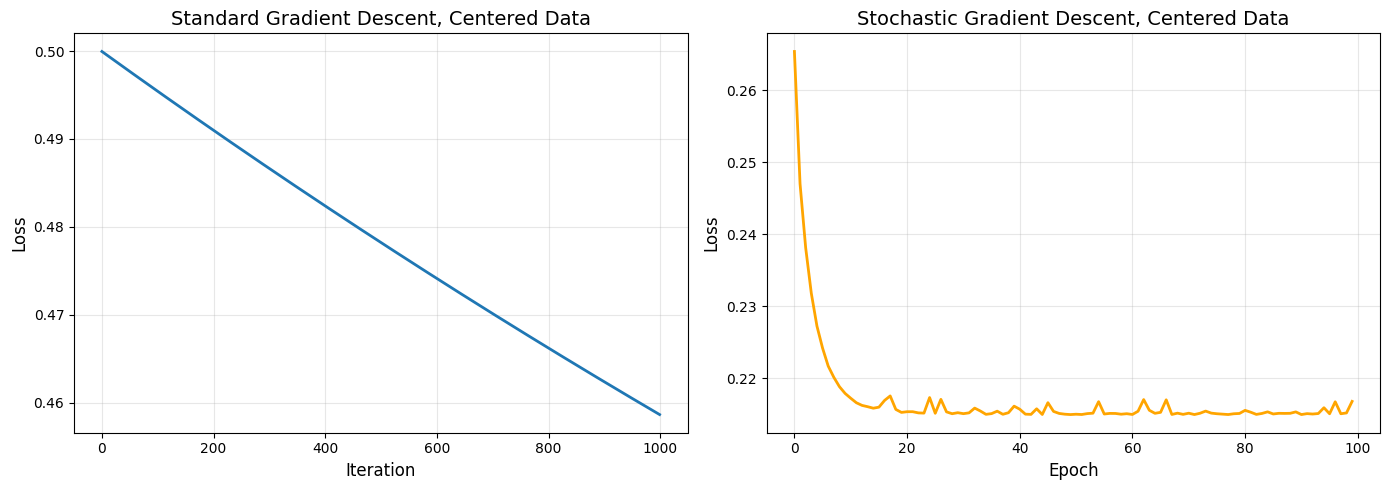

In [15]:
# Plot loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Standard GD loss curve
axes[0].plot(loss_history_center_gd, linewidth=2)
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Standard Gradient Descent, Centered Data', fontsize=14)
axes[0].grid(True, alpha=0.3)

# SGD loss curve
axes[1].plot(loss_history_center_sgd, linewidth=2, color='orange')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Stochastic Gradient Descent, Centered Data', fontsize=14)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Compare parameter estimates
comparison_center_df = pd.DataFrame({
    'Parameter': ['Bias', 'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'],
    'Standard GD': theta_center_gd.flatten(),
    'Stochastic GD': theta_center_sgd.flatten(),
    'Difference': np.abs(theta_center_gd.flatten() - theta_center_sgd.flatten())
})

print("Parameter Comparison (Centered Data):")
print(comparison_center_df.to_string(index=False))

Parameter Comparison (Centered Data):
 Parameter   Standard GD  Stochastic GD  Difference
      Bias  6.687239e-18      -0.000061    0.000061
    MedInc  6.098592e-02       0.690268    0.629282
  HouseAge  7.112754e-03       0.106077    0.098964
  AveRooms  9.846070e-03      -0.282641    0.292487
 AveBedrms -5.946092e-03       0.245221    0.251168
Population  1.078053e-03       0.007228    0.006150
  AveOccup -2.127475e-03      -0.042899    0.040771
  Latitude -1.413147e-02      -0.838378    0.824246
 Longitude -5.006426e-03      -0.811379    0.806372


# 8. Model Evaluation
To evaluate the four models, we compute the average error of the predictions.

In [17]:
# Make predictions
y_pred_center_gd = X_normalized_with_bias @ theta_center_gd
y_pred_center_sgd = X_normalized_with_bias @ theta_center_sgd

# Denormalize predictions for interpretability
y_pred_gd_decentered = y_pred_center_gd * y_std + y_mean
y_pred_sgd_decentered = y_pred_center_sgd * y_std + y_mean
y_actual = y

# Compute R-squared for both models
def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

r2_center_gd = r_squared(y_actual, y_pred_gd_decentered)
r2_center_sgd = r_squared(y_actual, y_pred_sgd_decentered)

print(f"R² Score (Standard GD Centered Data): {r2_center_gd:.4f}")
print(f"R² Score (Stochastic GD Centered Data): {r2_center_sgd:.4f}")

# RMSE
rmse_gd_center = np.sqrt(np.mean((y_actual - y_pred_gd_decentered) ** 2))
rmse_sgd_center = np.sqrt(np.mean((y_actual - y_pred_sgd_decentered) ** 2))

print(f"\nRMSE (Standard GD Centered Data): {rmse_gd_center * 100000:.2f} in target units")
print(f"RMSE (Stochastic GD Centered Data): {rmse_sgd_center * 100000:.2f} in target units")

R² Score (Standard GD Centered Data): 0.0827
R² Score (Stochastic GD Centered Data): 0.5664

RMSE (Standard GD Centered Data): 93580.06 in target units
RMSE (Stochastic GD Centered Data): 64341.64 in target units


We also visualize the predictions vs. errors as point clouds.

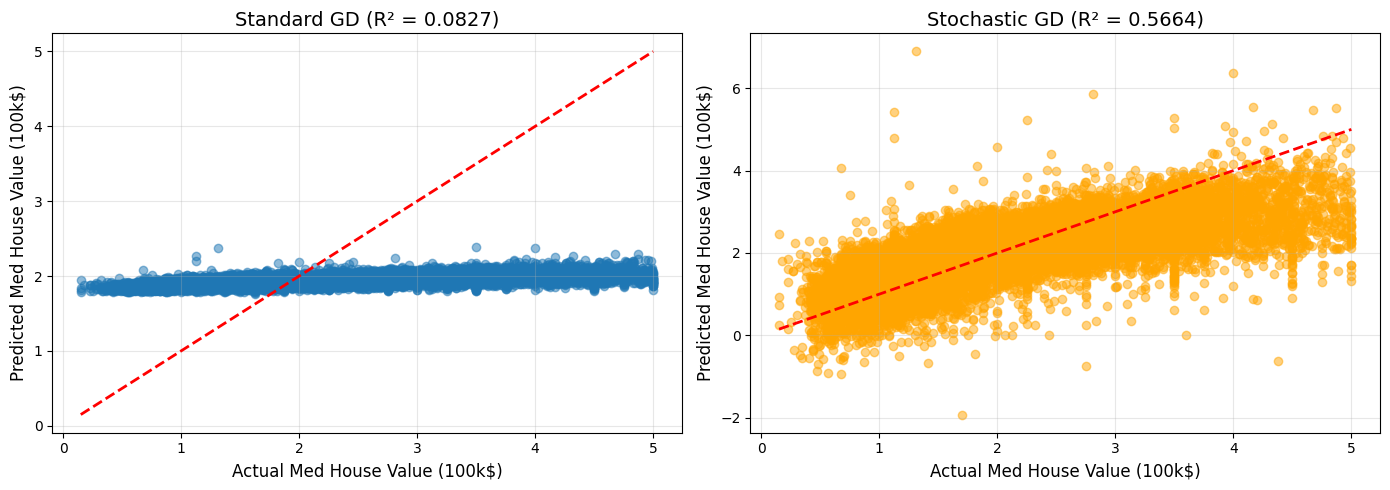

In [18]:
# Visualize predictions vs actual values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Standard GD Centered Data
axes[0].scatter(y_actual, y_pred_gd_decentered, alpha=0.5)
axes[0].plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Med House Value (100k$)', fontsize=12)
axes[0].set_ylabel('Predicted Med House Value (100k$)', fontsize=12)
axes[0].set_title(f'Standard GD (R² = {r2_center_gd:.4f})', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Stochastic GD Centered Data
axes[1].scatter(y_actual, y_pred_sgd_decentered, alpha=0.5, color='orange')
axes[1].plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Med House Value (100k$)', fontsize=12)
axes[1].set_ylabel('Predicted Med House Value (100k$)', fontsize=12)
axes[1].set_title(f'Stochastic GD (R² = {r2_center_sgd:.4f})', fontsize=14)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Problem 2: Assess the role of the step size in the performance of gradient descent


In [19]:
import time

#Step Sizes
step_sizes = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05]

In [24]:
results = []
for step in step_sizes:
  print(f"\n#################  Step size (learning_rate) = {step}   #############################")

  ### Batch GD
  #Training time
  t0 = time.perf_counter()
  theta_gd, loss_gd = gradient_descent(X_normalized_with_bias, y_normalized,learning_rate=step, n_iterations=1000)
  t1 = time.perf_counter()
  time_diff_gd = t1 - t0
  print(f"\nTime taken (GD): {time_diff_gd:.2f} seconds")
  print(f"\nBias: {theta_gd[0, 0]:.4f}")
  print(f"\nFinal Loss (GD): {loss_gd[-1]:.6f}")

  #Training Dataset performance
  y_pred_gd_center = X_normalized_with_bias @ theta_gd
  y_pred_gd = y_pred_gd_center * y_std + y_mean

  ss_res = np.sum((y - y_pred_gd) ** 2)
  ss_tot = np.sum((y - np.mean(y)) ** 2)
  r2 = 1 - (ss_res / ss_tot)
  print(f"\nR² Score (Standard GD Centered Data): {r2:.4f}")
  rmse = np.sqrt(np.mean((y - y_pred_gd) ** 2))
  print(f"\nRMSE (Standard GD Centered Data): {rmse * 100000:.2f} in target units")


  ###  SGD
  # Training time
  t0 = time.perf_counter()
  theta_sgd, loss_sgd = stochastic_gradient_descent(X_normalized_with_bias, y_normalized,learning_rate=step, n_epochs=100)
  t1 = time.perf_counter()
  time_diff_sgd = t1 - t0

  print(f"\nTime taken (SGD): {time_diff_sgd:.2f} seconds")
  print(f"\nBias (SGD): {theta_sgd[0, 0]:.4f}")
  print(f"\nFinal Loss (SGD): {loss_sgd[-1]:.6f}")

  # Training Dataset performance
  y_pred_sgd_center = X_normalized_with_bias @ theta_sgd
  y_pred_sgd = y_pred_sgd_center * y_std + y_mean

  ss_res = np.sum((y - y_pred_sgd) ** 2)
  ss_tot = np.sum((y - np.mean(y)) ** 2)
  r2_sgd = 1 - (ss_res / ss_tot)
  rmse_sgd = np.sqrt(np.mean((y - y_pred_sgd) ** 2))

  print(f"\nR² Score (Stochastic GD Centered Data): {r2_sgd:.4f}")
  print(f"\nRMSE (Stochastic GD Centered Data): {rmse_sgd * 100000:.2f} in target units")
  print("\n##################################################################################\n")

  results.append({
        "step_size": step,
        "batch_time_sec": time_diff_gd,
        "batch_final_loss": float(loss_gd[-1]),
        "batch_r2": float(r2),
        "batch_rmse_100k": float(rmse),
        "batch_rmse_dollars": float(rmse * 100000),

        "sgd_time_sec": time_diff_sgd,
        "sgd_final_loss": float(loss_sgd[-1]),
        "sgd_r2": float(r2_sgd),
        "sgd_rmse_100k": float(rmse_sgd),
        "sgd_rmse_dollars": float(rmse_sgd * 100000),
    })
results_df = pd.DataFrame(results).sort_values("step_size").reset_index(drop=True)



#################  Step size (learning_rate) = 0.0001   #############################

Time taken (GD): 0.29 seconds

Bias: 0.0000

Final Loss (GD): 0.458635

R² Score (Standard GD Centered Data): 0.0827

RMSE (Standard GD Centered Data): 93580.06 in target units

Time taken (SGD): 15.33 seconds

Bias (SGD): -0.0001

Final Loss (SGD): 0.216813

R² Score (Stochastic GD Centered Data): 0.5664

RMSE (Stochastic GD Centered Data): 64341.64 in target units

##################################################################################


#################  Step size (learning_rate) = 0.0005   #############################

Time taken (GD): 0.28 seconds

Bias: -0.0000

Final Loss (GD): 0.356003

R² Score (Standard GD Centered Data): 0.2880

RMSE (Standard GD Centered Data): 82447.27 in target units

Time taken (SGD): 16.52 seconds

Bias (SGD): 0.0067

Final Loss (SGD): 0.251155

R² Score (Stochastic GD Centered Data): 0.4977

RMSE (Stochastic GD Centered Data): 69250.12 in target units



/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipython-input-3074507971.py:9: RuntimeWarning: overflow encountered in square
  loss = (1 / (2 * m)) * np.sum(errors ** 2)
/tmp/ipython-input-1003883284.py:23: RuntimeWarning: overflow encountered in matmul
  gradient = xi.T @ error  # No division by m since we're using one sample
/tmp/ipython-input-1003883284.py:26: RuntimeWarning: invalid value encountered in subtract
  theta = theta - learning_rate * gradient
/tmp/ipython-input-1003883284.py:21: RuntimeWarning: invalid value encountered in matmul
  prediction = xi @ theta



Time taken (SGD): 15.34 seconds

Bias (SGD): nan

Final Loss (SGD): nan

R² Score (Stochastic GD Centered Data): nan

RMSE (Stochastic GD Centered Data): nan in target units

##################################################################################


#################  Step size (learning_rate) = 0.01   #############################

Time taken (GD): 0.28 seconds

Bias: -0.0000

Final Loss (GD): 0.226929

R² Score (Standard GD Centered Data): 0.5461

RMSE (Standard GD Centered Data): 65825.60 in target units

Time taken (SGD): 16.28 seconds

Bias (SGD): nan

Final Loss (SGD): nan

R² Score (Stochastic GD Centered Data): nan

RMSE (Stochastic GD Centered Data): nan in target units

##################################################################################


#################  Step size (learning_rate) = 0.05   #############################

Time taken (GD): 0.38 seconds

Bias: -0.0000

Final Loss (GD): 0.215032

R² Score (Standard GD Centered Data): 0.5699

RMSE (Stand

 step_size  batch_time_sec  batch_final_loss  batch_r2  batch_rmse_100k  batch_rmse_dollars  sgd_time_sec  sgd_final_loss         sgd_r2  sgd_rmse_100k  sgd_rmse_dollars
    0.0001        0.287435          0.458635  0.082730         0.935801        93580.062446     15.330949    2.168128e-01   5.663744e-01   6.434164e-01      6.434164e+04
    0.0005        0.278031          0.356003  0.287995         0.824473        82447.270252     16.522685    2.511549e-01   4.976902e-01   6.925012e-01      6.925012e+04
    0.0010        0.273299          0.300321  0.399358         0.757256        75725.563305     16.268067   2.598282e+224 -5.196565e+224  2.227373e+112     2.227373e+117


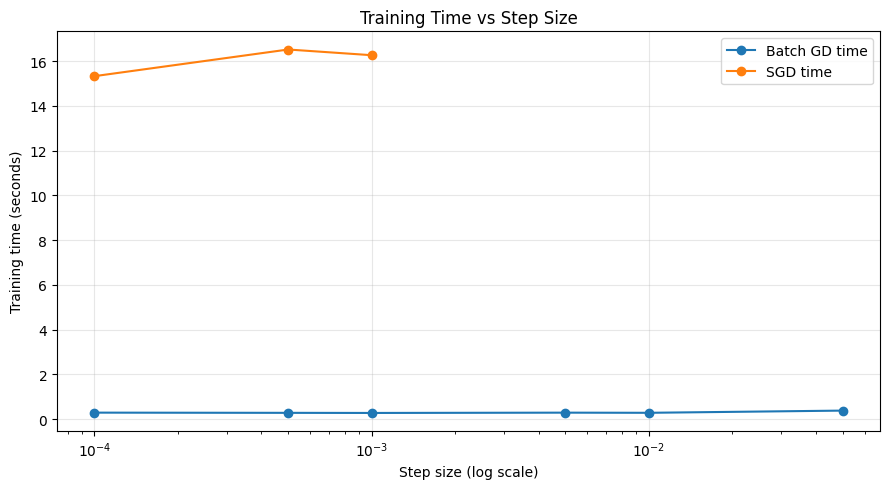

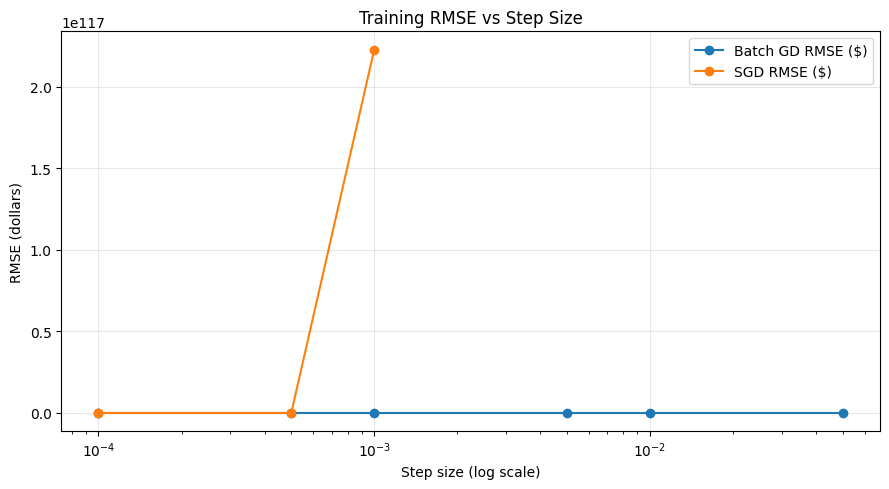

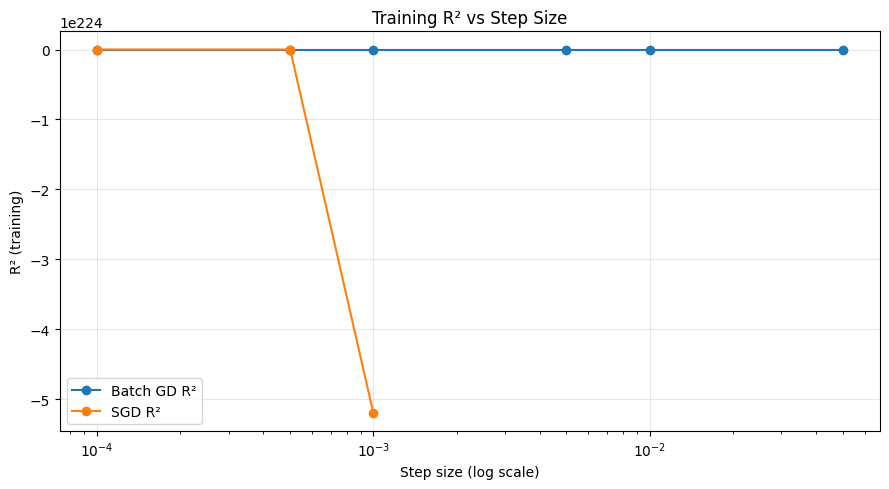

In [28]:
#print("\nSummary table (training set performance):")
results_df_sgd_clean = results_df.dropna(subset=["sgd_r2", "sgd_rmse_dollars", "sgd_time_sec"])
print(results_df_sgd_clean.to_string(index=False))

# Plot: runtime vs step size (Batch vs SGD)
plt.figure(figsize=(9, 5))
plt.plot(results_df["step_size"], results_df["batch_time_sec"], marker="o", label="Batch GD time")
plt.plot(results_df_sgd_clean["step_size"], results_df_sgd_clean["sgd_time_sec"], marker="o", label="SGD time")
plt.xscale("log")
plt.xlabel("Step size (log scale)")
plt.ylabel("Training time (seconds)")
plt.title("Training Time vs Step Size")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot: RMSE vs step size (Batch vs SGD)
plt.figure(figsize=(9, 5))
plt.plot(results_df["step_size"], results_df["batch_rmse_dollars"], marker="o", label="Batch GD RMSE ($)")
plt.plot(results_df_sgd_clean["step_size"], results_df_sgd_clean["sgd_rmse_dollars"], marker="o", label="SGD RMSE ($)")
plt.xscale("log")
plt.xlabel("Step size (log scale)")
plt.ylabel("RMSE (dollars)")
plt.title("Training RMSE vs Step Size")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot: R^2 vs step size (Batch vs SGD)
plt.figure(figsize=(9, 5))
plt.plot(results_df["step_size"], results_df["batch_r2"], marker="o", label="Batch GD R²")
plt.plot(results_df_sgd_clean["step_size"], results_df_sgd_clean["sgd_r2"], marker="o", label="SGD R²")
plt.xscale("log")
plt.xlabel("Step size (log scale)")
plt.ylabel("R² (training)")
plt.title("Training R² vs Step Size")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Problem 3

In [29]:
from sklearn.model_selection import train_test_split

In [31]:
best_lr_gd = 0.05
best_lr_sgd = 0.0001

lambda_values = [0, 0.1, 1, 10, 100, 1000]

n_splits = 5
test_size = 0.2

In [32]:
def compute_ridge_loss(X, y, theta, lam):
    """
    Ridge loss:
    (1/(2m)) * sum((X theta - y)^2) + lam * ||theta_no_bias||^2
    """
    m = len(y)
    predictions = X @ theta
    errors = predictions - y
    data_loss = (1 / (2 * m)) * np.sum(errors ** 2)

    theta_no_bias = theta[1:, :]
    reg_loss = lam * np.sum(theta_no_bias ** 2)

    return data_loss + reg_loss


def compute_ridge_gradient(X, y, theta, lam):
    """
    Gradient of ridge loss:
    (1/m) * X^T (X theta - y) + 2*lam*theta_no_bias (bias term excluded)
    """
    m = len(y)
    predictions = X @ theta
    errors = predictions - y

    grad = (1 / m) * (X.T @ errors)

    reg = np.zeros_like(theta)
    reg[1:, :] = 2 * lam * theta[1:, :]
    grad = grad + reg

    return grad


In [33]:
def ridge_gradient_descent(X, y, lam, learning_rate=0.01, n_iterations=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    loss_history = []

    for i in range(n_iterations):
        gradient = compute_ridge_gradient(X, y, theta, lam)
        theta = theta - learning_rate * gradient

        loss = compute_ridge_loss(X, y, theta, lam)
        loss_history.append(loss)

    return theta, loss_history

In [34]:
def ridge_stochastic_gradient_descent(X, y, lam, learning_rate=0.01, n_epochs=100, random_seed=42):
    np.random.seed(random_seed)
    m, n = X.shape
    theta = np.zeros((n, 1))
    loss_history = []

    for _ in range(n_epochs):
        indices = np.random.permutation(m)

        for i in indices:
            xi = X[i:i+1, :]
            yi = y[i:i+1, :]

            prediction = xi @ theta
            error = prediction - yi

            grad = xi.T @ error  # SGD version of OLS part, no division by m

            reg = np.zeros_like(theta)
            reg[1:, :] = 2 * lam * theta[1:, :]
            grad = grad + reg

            theta = theta - learning_rate * grad

        loss = compute_ridge_loss(X, y, theta, lam)
        loss_history.append(loss)

    return theta, loss_history

In [35]:
def evaluate_centered_model(X_norm_bias, y_true, theta, y_mean, y_std):
    y_pred_centered = X_norm_bias @ theta
    y_pred = y_pred_centered * y_std + y_mean

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return r2, rmse

In [36]:
cv_rows = []

print("\nStarting Problem 3 Ridge Regression cross validation...")

for lam in lambda_values:
    gd_rmse_list = []
    sgd_rmse_list = []

    gd_time_list = []
    sgd_time_list = []

    print(f"\nLambda = {lam}")

    for split_id in range(n_splits):
        X_tr, X_va, y_tr, y_va = train_test_split(
            X_normalized_with_bias, y_normalized,
            test_size=test_size,
            random_state=split_id,
            shuffle=True
        )

        # Batch GD training on this split
        t0 = time.perf_counter()
        theta_gd, loss_gd = ridge_gradient_descent(
            X_tr, y_tr,
            lam=lam,
            learning_rate=best_lr_gd,
            n_iterations=1000
        )
        gd_time = time.perf_counter() - t0

        # Validation metrics: use y in original units
        y_va_orig = y_va * y_std + y_mean
        r2_gd, rmse_gd = evaluate_centered_model(X_va, y_va_orig, theta_gd, y_mean, y_std)

        gd_rmse_list.append(float(rmse_gd))
        gd_time_list.append(float(gd_time))

        # SGD training on this split
        t0 = time.perf_counter()
        theta_sgd, loss_sgd = ridge_stochastic_gradient_descent(
            X_tr, y_tr,
            lam=lam,
            learning_rate=best_lr_sgd,
            n_epochs=100,
            random_seed=split_id
        )
        sgd_time = time.perf_counter() - t0

        # If SGD diverges, rmse becomes nan, which is useful to record
        r2_sgd, rmse_sgd = evaluate_centered_model(X_va, y_va_orig, theta_sgd, y_mean, y_std)

        sgd_rmse_list.append(float(rmse_sgd))
        sgd_time_list.append(float(sgd_time))

    # Store average CV results for this lambda
    cv_rows.append({
        "lambda": lam,

        "batch_avg_rmse_100k": float(np.nanmean(gd_rmse_list)),
        "batch_avg_rmse_dollars": float(np.nanmean(gd_rmse_list) * 100000),
        "batch_avg_time_sec": float(np.nanmean(gd_time_list)),

        "sgd_avg_rmse_100k": float(np.nanmean(sgd_rmse_list)),
        "sgd_avg_rmse_dollars": float(np.nanmean(sgd_rmse_list) * 100000),
        "sgd_avg_time_sec": float(np.nanmean(sgd_time_list)),
    })

cv_df = pd.DataFrame(cv_rows).sort_values("lambda").reset_index(drop=True)

print("\nCross validation summary (lower RMSE is better):")
print(cv_df.to_string(index=False))


Starting Problem 3 Ridge Regression cross validation...

Lambda = 0

Lambda = 0.1

Lambda = 1

Lambda = 10

Lambda = 100


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipython-input-2200179022.py:9: RuntimeWarning: overflow encountered in square
  data_loss = (1 / (2 * m)) * np.sum(errors ** 2)
/tmp/ipython-input-2200179022.py:12: RuntimeWarning: overflow encountered in scalar multiply
  reg_loss = lam * np.sum(theta_no_bias ** 2)
/tmp/ipython-input-2200179022.py:12: RuntimeWarning: overflow encountered in square
  reg_loss = lam * np.sum(theta_no_bias ** 2)
/tmp/ipython-input-2200179022.py:26: RuntimeWarning: overflow encountered in matmul
  grad = (1 / m) * (X.T @ errors)
/tmp/ipython-input-2200179022.py:7: RuntimeWarning: invalid value encountered in matmul
  predictions = X @ theta
/tmp/ipython-input-2200179022.py:23: RuntimeWarning: invalid value encountered in matmul
  predictions = X @ theta
/tmp/ipython-input-2200179022.py:26: RuntimeWarning: invalid value encount


Lambda = 1000

Cross validation summary (lower RMSE is better):
 lambda  batch_avg_rmse_100k  batch_avg_rmse_dollars  batch_avg_time_sec  sgd_avg_rmse_100k  sgd_avg_rmse_dollars  sgd_avg_time_sec
    0.0             0.649079            64907.862038            0.462863           0.647967          64796.688641         23.289810
    0.1             0.696637            69663.733365            0.399981           0.696359          69635.869521         22.690684
    1.0             0.845694            84569.354309            0.449143           0.845878          84587.770042         23.298218
   10.0             0.957923            95792.323183            0.386082           0.958202          95820.162020         23.552013
  100.0                  NaN                     NaN            0.409617           0.976873          97687.293864         23.539831
 1000.0                  NaN                     NaN            0.471519           0.978694          97869.407943         23.311856
